In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv(r"C:\Users\Faisal\Downloads\IPL.csv")


In [3]:
'''Display comprehensive information about the DataFrame including data types, 
non-null counts, and memory usage'''
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

### Print the number of rows and columns in the DataFrame

In [4]:
print(f"Rows are {df.shape[0]}{"\n"}columns are {df.shape[1]} ")

Rows are 74
columns are 20 


### Check for missing value in each column

In [6]:
print(df.isnull().sum())

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64


### Top 10 performer of Match

Text(0, 0.5, 'Team name')

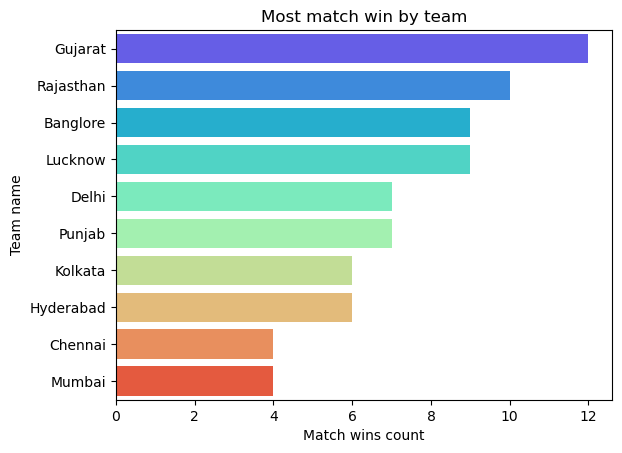

In [20]:
# Count the number of match wins for each team
match_wins = df["match_winner"].value_counts()

# Create a horizontal bar plot showing match wins by team
sns.barplot(x = match_wins.values,y = match_wins.index,palette="rainbow")

# Add title and axis labels to the plot
plt.title("Most match win by team")
plt.xlabel("Match wins count")
plt.ylabel("Team name")

### Toss Decision Trend

Text(0.5, 0, 'Toss Decision')

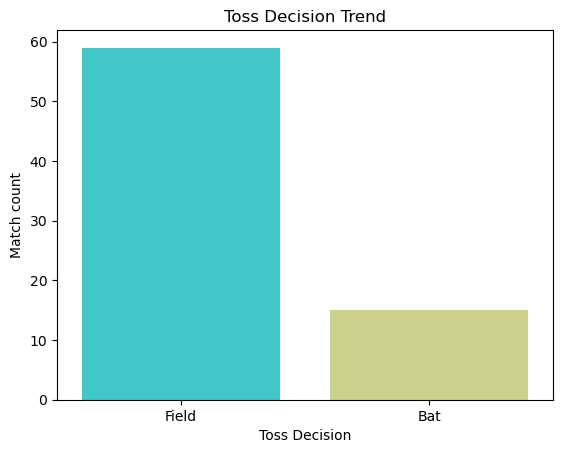

In [8]:
# method 1: find trend whether Toss win team decide Fielding or Batting
# Create a simple count plot to visualize toss decision distribution
sns.countplot(x = df["toss_decision"])

# method 2: find trend whether Toss win team decide Fielding or Batting
# Get value counts for each toss decision (bat/field)
toss_win = df["toss_decision"].value_counts()
# Create a bar plot using the count.
sns.barplot(x = toss_win.index,y = toss_win.values,palette="rainbow")

# Add title and axis labels to the plot
plt.title("Toss Decision Trend")
plt.ylabel("Match count")
plt.xlabel("Toss Decision")

### Is there any relation between Toss win team and Match win team?

In [9]:
# Count the number of matches where Toss winner also won the match 
count = df[df["toss_winner"] == df["match_winner"]]["match_id"].count()

# Calculating Percentage.
percentage = (count*100)/df.shape[0]
percentage = percentage.round(2)
# Display the final percentage
print(percentage)

48.65


Text(0, 0.5, 'Matchs win')

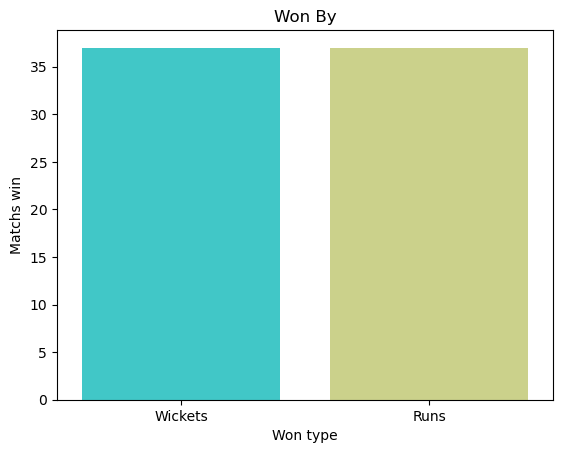

In [21]:
# Create a count plot to visualize the distribution of match win by tyoe (Wicket & Run)
sns.countplot(x = df["won_by"],palette="rainbow")

# Add title and axis labels to the plot
plt.title("Won By")
plt.xlabel("Won type")
plt.ylabel("Matchs win")

### Top 10 Player with Man of the Match

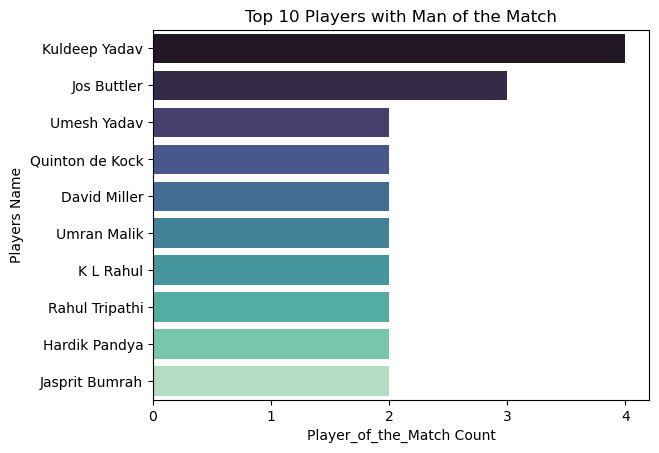

In [23]:
# Get the Top 10 players who win most Man of the Match award
count = df["player_of_the_match"].value_counts().head(10)

# Create a horizontal bar plot using seaborn with 'mako' colour palette
sns.barplot(x = count.values,y = count.index,palette="mako")

# Add title and axis labels to the plot
plt.title("Top 10 Players with Man of the Match")
plt.ylabel("Players Name")
plt.xlabel("Player_of_the_Match Count")

# Set x-axis tick marks at positions 0, 1, 2, 3, 4
plt.xticks(range(5));

### Top 2 Players with highest Scores sum

<Axes: ylabel='top_scorer'>

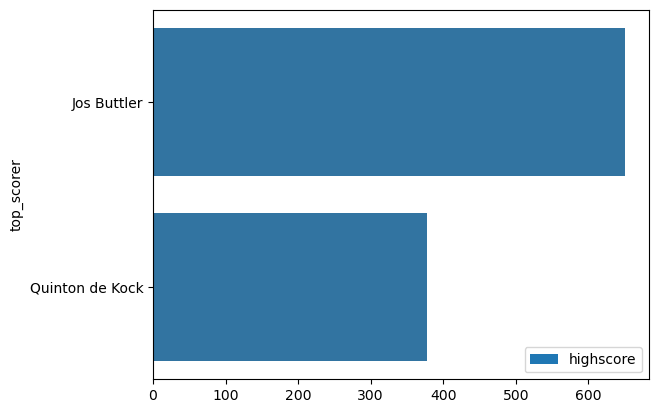

In [12]:
# Group data by top scorer and sum their high score, then sort in descending order and get top 2
high_scorers = df.groupby("top_scorer")["highscore"].sum().sort_values(ascending=False).head(2)

# Method 1: Create horizontal bar chart using pandas built-in plotting 
high_scorers.plot(kind = "barh")

# Method 2: Create horizontal bar chart using seaborn
sns.barplot(x = high_scorers.values,y = high_scorers.index) # method 2

### Top 10 Bowler by wicket count

Text(0, 0.5, 'Player Name')

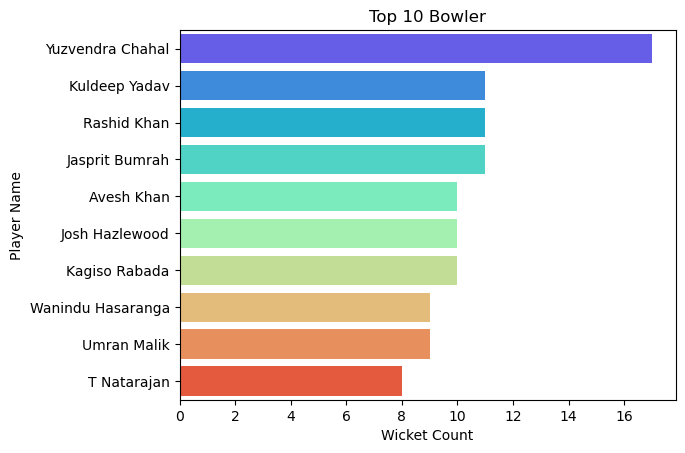

In [13]:
# Extract wicket count from bowling figures(format: "wickets--runs")
wicket = df["highest_wicket"] = df["best_bowling_figure"].apply(lambda x :x.split("--")[0]) # extract wicket

# Change wicket count from string to integer for numerical operation
df["highest_wicket"] = df['highest_wicket'].astype(int)

# Group by bowler name, sum their wickets, sort in descending order, and get top 10
top_bowler = df.groupby("best_bowling")["highest_wicket"].sum().sort_values(ascending=False).head(10) # sort and select only top 10

# Create horizontal bar plot showing top 10 bowler by wicket 
sns.barplot(x = top_bowler.values,y = top_bowler.index,palette="rainbow") # ploting graph

# Add title and axis labels to the plot
plt.title("Top 10 Bowler")
plt.xlabel("Wicket Count")
plt.ylabel("Player Name")

Text(0.5, 0, 'Match Count')

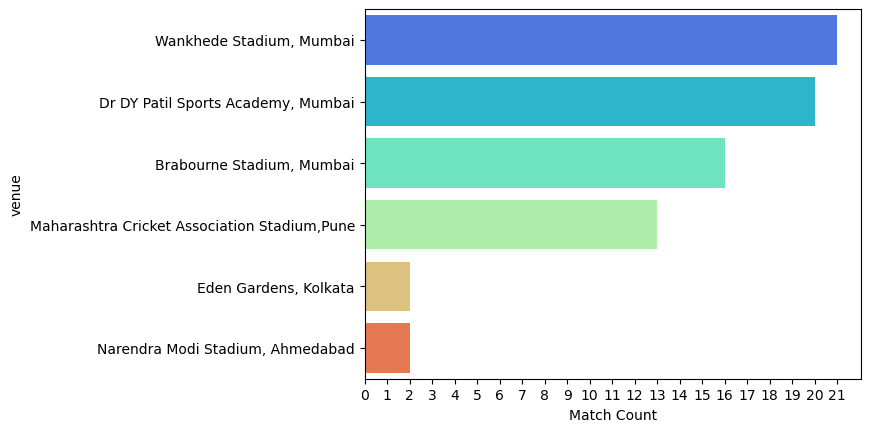

In [14]:
# Count the frequency of match played at each venue/stadium
stadium_count = df["venue"].value_counts()

# Create a horizontal bar plot showing match count by venue
sns.barplot(x = stadium_count.values,y = stadium_count.index,palette="rainbow")

# Set x-axis tick marks from 0 to maximum match count
plt.xticks(range(stadium_count.max()+1)); # by using semicolon unecessary output blocked

plt.xlabel("Match Count")

### Who won match by highest margin on the basis of Run ?

In [16]:
df[df["won_by"] == "Runs"].sort_values(by = "margin",ascending=False).head(1)[["match_winner","margin"]]

,match_winner,margin
54,Chennai,91


In [17]:
df[df["highscore"] == df["highscore"].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140
